In [13]:
import numpy as np
import pandas as pd
df = pd.read_csv('agriculture_yield_dataset.csv',sep = ",")

In [4]:
#question 1 dataset overview
print("No of rows and columns", df.shape)
print("No of columns", df.columns)
print("First 10 columns", df.head(10))

No of rows and columns (1500, 8)
No of columns Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
First 10 columns    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5    

In [5]:
#question no 2 data types and mising values
print("Data types", df.dtypes)
print("Missing values", df.isnull().sum())
print("Affected columns" ,df.columns[df.isnull().any()])

Data types rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
Missing values rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64
Affected columns Index([], dtype='object')


In [6]:
# question no 3 descriptive statastics
import matplotlib.pyplot as plt
import seaborn as sns
stats = df.describe()
print(stats)

print("\nFeature with Highest Mean:")
print(stats.loc['mean'].idxmax())

print("\nFeature with Highest Std Dev:")
print(stats.loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

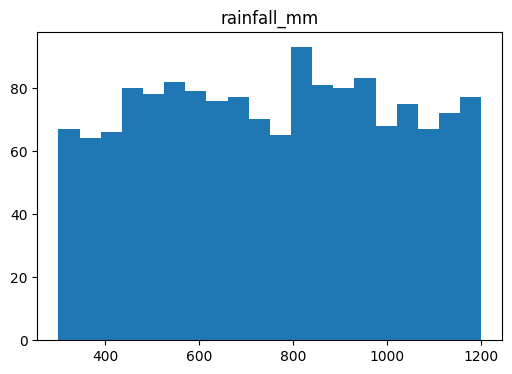

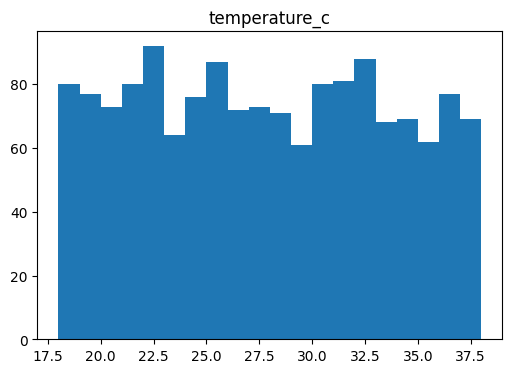

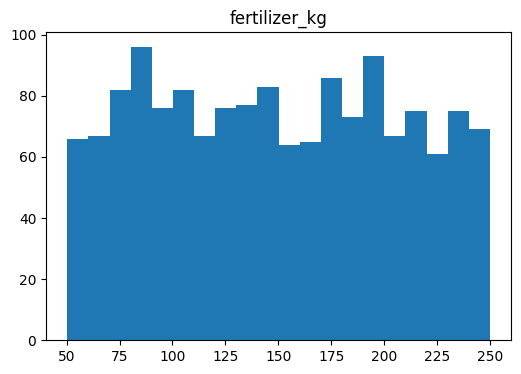

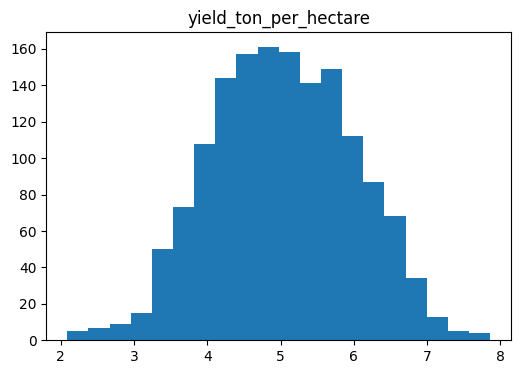

In [7]:
# question no 4 distribution analysis
cols = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]

for col in cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


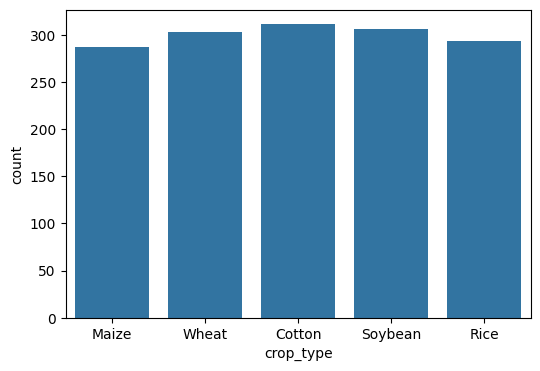

Most Frequent Crop:
Cotton


In [8]:
# crop tree analysis
print(df['crop_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.show()

print("Most Frequent Crop:")
print(df['crop_type'].mode()[0])

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


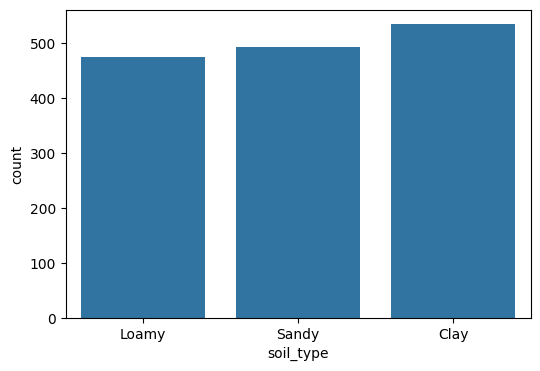

Most Common Soil Type:
Clay


In [9]:
#soil type analysis
print(df['soil_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.show()

print("Most Common Soil Type:")
print(df['soil_type'].mode()[0])

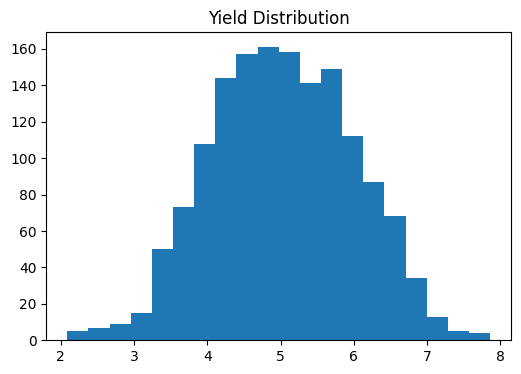

In [10]:
#yeild distribution
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title('Yield Distribution')
plt.show()

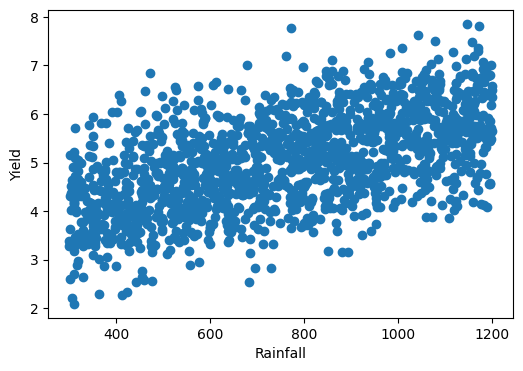

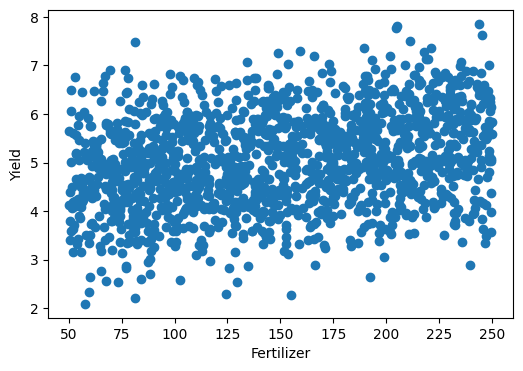

In [11]:
#scatter plot analysis
plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel('Fertilizer')
plt.ylabel('Yield')
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

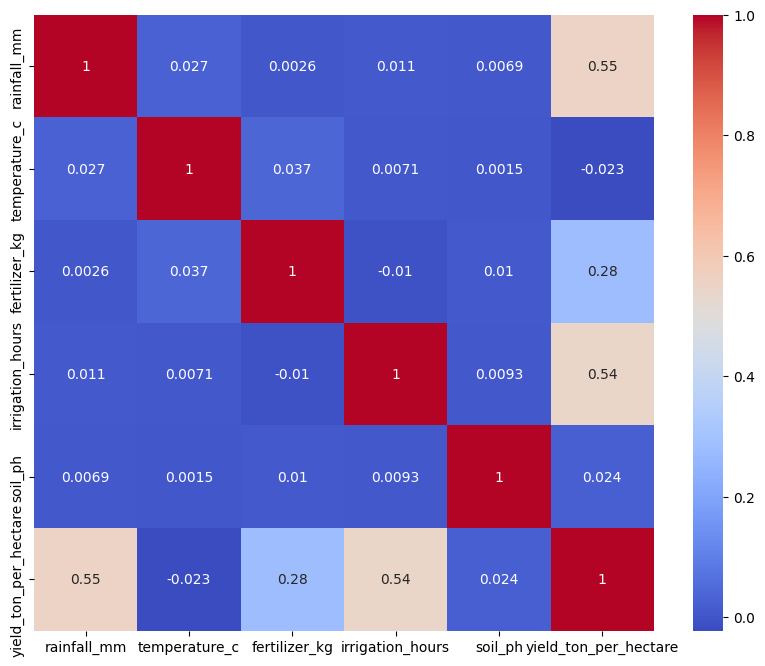

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [14]:
# corelation analysis
corr = df.select_dtypes(include=np.number).corr()

print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

print(
    corr['yield_ton_per_hectare']
    .sort_values(ascending=False)
)

In [15]:
#group based analysis
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_yield)

soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_yield)

print("Highest Yield Crop:")
print(crop_yield.idxmax())

print("Highest Yield Soil:")
print(soil_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Yield Crop:
Rice
Highest Yield Soil:
Loamy


In [16]:
# feature encoding
cat_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(cat_cols)

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

print(df_encoded.head())

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False  

In [17]:
# feature selection
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

Input Features:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean',
       'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy'],
      dtype='object')

Target Variable:
yield_ton_per_hectare


In [18]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [19]:
# linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff)

print("\nHighest Positive Coefficient:")
print(
    coeff.sort_values(
        by='Coefficient',
        ascending=False
    ).head(1)
)

Intercept:
1.587132027736121
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Highest Positive Coefficient:
          Feature  Coefficient
6  crop_type_Rice     0.863993
